# DBSCAN and Hierarchical Clustering
## Learning Objectives
At the completion of this notebook, we should be able to:
- Describe the shortcomings of K-Means.
- Discuss scenarios where DBSCAN is better suited than K-Means.
- Implement DBSCAN and recognize noise points.
- Comprehend the concepts of eps and min_samples.
- Generate and analyze a dendrogram using Hierarchical Clustering.
- Decide on the height cut off point and the number of clusters formed.
- Compare K-Means, DBSCAN, and Hierarchical Clustering.
- Determine the most appropriate clustering technique for our data set.

## Import Libraries

In [43]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from scipy.cluster.hierarchy import dendrogram,linkage
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster


## 2. Load the Dataset
**We use the same Credit Card Fraud Detection dataset from Day 1.**
The goal of this training is not to predict whether a transaction is fraudulent.
Instead, we use clustering to discover groups of transactions based on their numerical features,because clustering is an unsupervised learning technique, we do not use the fraud label when creating the clusters.

In [44]:
df=pd.read_csv("creditcard.csv")
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


## Inspect the dataset
Befor applying clustering we check:
- The number of rows and columns.
- The data types.
- Missing values.
Clustering algorithms work with numerical features ,so we need to select appropraite numerical columns befor applying the algorithms.

In [45]:
df.shape

(284807, 31)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [47]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

##  Prepare the Features
The "Class" attribute indicates whether the transaction is fraud.
We do not want to consider "Class" as one of the input attributes since clustering is an unsupervised technique.
Including the target variable while making clusters will lead to incorporating information which should not be known by the algorithm.
We will ignore the "Time" attribute since it contains time details of the transactions and not transaction activity
All other numerical transaction attributes will be included in clustering.

In [48]:
x = df.drop(columns=["Class", "Time"])
x.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


## Feature Scaling
The DBSCAN algorithm and hierarchical clustering work with the distance between data points,when one feature is scaled differently compared to other features, it can affect the distance calculation.
Thus, we normalize the features prior to clustering.
StandardScaler scales the features such that they:
- mean=0
- standard deviation=1

In [49]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled.shape

(284807, 29)

## 6. Why K-Means Isn't Always Enough
K-Means works fine for clustering where the clusters are fairly tight and similarly shaped and sized.
But there are several problems with using K-Means:
1. We need to know how many clusters there will be (the value of k) beforehand.
2. It works well for tight, circular clusters.
3. Each data point gets a cluster.
4. It doesn't explicitly find outliers.
Because of all this, we will compare K-Means to DBSCAN and hierarchical clustering.

In [24]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
kmenas_labels=kmeans.fit_predict(x_scaled)

In [50]:
np.unique(kmenas_labels,return_counts=True)

(array([0, 1, 2], dtype=int32), array([ 20196, 259336,   5275]))

### K-Means Output
The output shows the number of data points in each K-Means cluster,aSs every data point belongs to some K-Means cluster, there is no special “noise” label.

## DBSCAN
DBSCAN is an acronym for Density-Based Spatial Clustering of Applications with Noise.
Rather than making us specify the number of clusters, DBSCAN uses the density of points around each other to discover clusters.
It has two primary hyperparameters:
- eps: max distance between points to consider them neighbors.
- min_samples: minimum number of neighbors necessary to form a dense cluster.
An important aspect of DBSCAN is its ability to tag points as outliers/noise.
A point tagged with a label of -1 is considered to be noise/outlier.

In [51]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
dbscan_labels=dbscan.fit_predict(x_scaled)

## Understanding eps and min_samples
### eps
eps is a value that determines the distance between two data points so that they can be considered neighbors.
- If eps is smaller, fewer neighbors will be selected, possibly leading to higher noise.
- If eps is larger, more neighbors will be considered, possibly resulting in large clusters or clustering of clusters.
### min_samples
min_samples is a value that determines the number of neighbors needed to define a dense region.
- The greater min_samples, the denser the region will be.
- The lesser min_samples, the easier it is to define a dense region.
The selection of these two variables can greatly influence the results of DBSCAN algorithm.

## Inspect DBSCAN Results

In [52]:
unique_labels = np.unique(dbscan_labels)

In [53]:
n_clusters_dbscan=len(set(dbscan_labels)) -(1 if -1 in dbscan_labels else 0)
n_noise=np.sum(dbscan_labels==-1)
print("Number of clusters is:",n_clusters_dbscan)
print("Number of noise points:",n_noise)

Number of clusters is: 3202
Number of noise points: 200552


## DBSCAN Output
DBSCAN output is:
- No. of clusters = [3202]
- No. of points labelled noise = [200552]
Points labelled `-1` constitute noise points and not clusters.
Thus, it clearly illustrates one of the biggest strengths of DBSCAN algorithm over K-Means algorithm; namely, the ability to detect noise points.

#  Hierarchical Clustering
Hierarchical clustering results in a tree-like structure of clusters.
At first, each observation is treated as an individual cluster,then, the algorithm continuously joins the closest clusters till all observations end up in one big cluster,this can be represented in a form of a dendrogram.
The dendrogram helps to find out the appropriate height for the cutting of the tree and creation of the needed number of clusters.

### Sample for Dendrogram
Credit Card dataset is a dataset having a huge number of data points.
Hierarchical Clustering dendrogram on complete dataset will become computationally costly,thus, we perform hierarchical clustering analysis using a representative sample,it doesn’t affect the objective which is to visualize the structure and make a cut.

In [54]:
sample_size = min(1000, len(x_scaled))
rng = np.random.RandomState(42)
sample_indices = rng.choice(len(x_scaled),size=sample_size,replace=False)
x_sample = x_scaled[sample_indices]
print(x_sample.shape)

(1000, 29)


In [55]:
my_linkage_matrix = sch.linkage(x_sample,method="ward")
print(my_linkage_matrix.shape)

(999, 4)


## Hierarchical Clustering Dendrogram
Hierarchical clustering builds a hierarchy of clusters by progressively merging observations based on their similarity.
The dendrogram visualizes these merging steps. By selecting a horizontal cut at a chosen distance, we can determine the resulting number of clusters.

In [56]:
z=linkage(x_sample,method="ward")

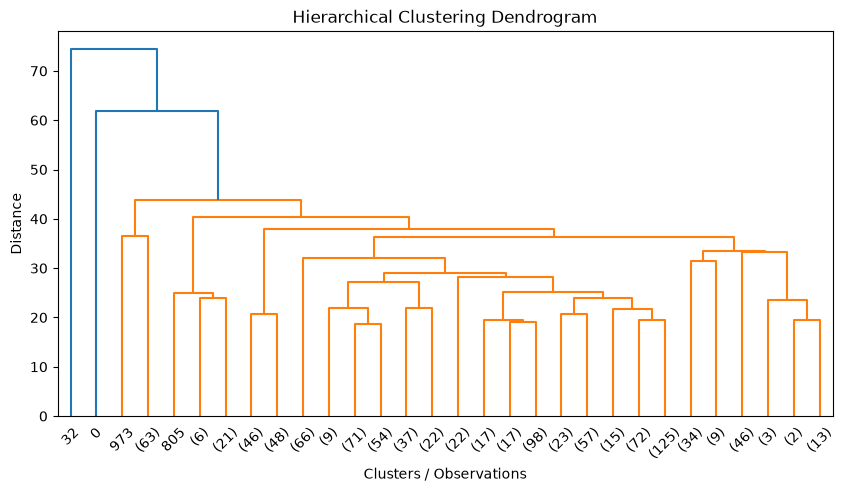

In [ ]:
sch.dendrogram(my_linkage_matrix,truncate_mode="lastp",p=30)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters / Observations")
plt.ylabel("Distance")
plt.show()

## Interpretation of the Dendrogram
The vertical axis measures the distance at which clusters get merged,if the distance is relatively high, then there will be large vertical spaces between nodes,an imaginary line can be drawn horizontally in the dendrogram.
The number of branches intersected by this line equals the number of clusters created.
In this case, we make a good choice of the cut-off point for the dendrogram.
Note: The dendrogram is truncated to the last 30 branches for readability. The hierarchical clustering itself was performed on all 1,000 sampled observations using all 29 scaled features.

### Choosing a Cut Height
The dendrogram shows a relatively large increase in distance between approximately 44 and 62. Therefore, a cut height of 50 was selected because it falls within this gap and provides a clear separation between the main groups.
At this cut height, the hierarchical clustering produces 3 clusters.

In [57]:
cut_height = 50
hierarchical_labels = fcluster(my_linkage_matrix,t=cut_height,criterion="distance")
n_clusters_hierarchical = len(np.unique(hierarchical_labels))
print("Selected cut height:", cut_height)
print("Number of hierarchical clusters:", n_clusters_hierarchical)

Selected cut height: 50
Number of hierarchical clusters: 3


In [32]:
cluster_counts = np.unique(hierarchical_labels,return_counts=True)
print("Cluster labels:", cluster_counts[0])
print("Number of observations in each cluster:", cluster_counts[1])

Cluster labels: [1 2 3]
Number of observations in each cluster: [998   1   1]


### Hierarchical Clustering Visualization
The hierarchical clustering algorithm was performed using all 29 scaled features. For visualization, the first two features are displayed in a scatter plot, while the cluster labels were generated using all features.

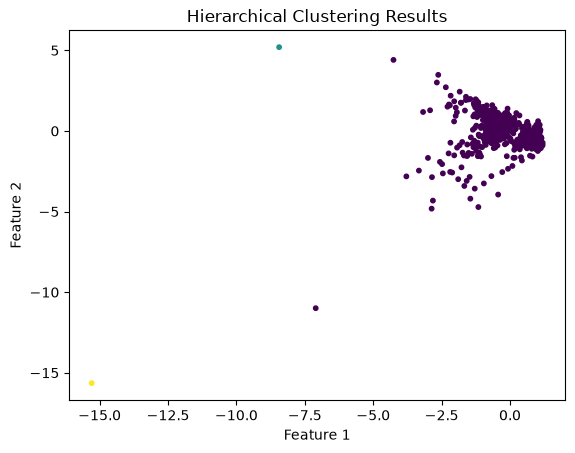

In [33]:
plt.scatter(x_sample[:, 0],x_sample[:, 1],c=hierarchical_labels,s=10)
plt.title("Hierarchical Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [29]:
from scipy.cluster.hierarchy import fcluster
n_hierarchical_clusters = 3
hierarchical_labels = fcluster(z,t=n_hierarchical_clusters,criterion="maxclust")
print("Number of clusters:", len(np.unique(hierarchical_labels)))

Number of clusters: 3


Hierarchical Clustering
A hierarchical clustering dendrogram was constructed, and we chose a cut which creates *3 clusters*.
The number of clusters after the cut is:
*3 clusters*
The dendrogram will help us understand how the observations are being combined gradually and select the appropriate clustering level.

# Comparison of K-Means, DBSCAN, and Hierarchical Clustering Algorithms
Here, we make a comparison of the three clustering methods using the same data.
### K-Means
- Number of clusters must be determined in advance.
- Every point is assigned a cluster.
- Works well with compact and rather spherical clusters.
### DBSCAN
- Does not require the number of clusters in advance.
- Can detect outliers and noise.
- Can find non-spherical clusters.
- Very sensitive to eps and min_samples values.
### Hierarchical Clustering
- Creates clusters hierarchically.
- Shows a dendrogram with the cluster merging process.
- We can decide on the level of clustering after looking at the hierarchy.

In [42]:
comparison_df = pd.DataFrame({"Clustering Method": ["K-Means","DBSCAN","Hierarchical"],"Number of Clusters": [len(np.unique(kmeans_sample_labels)),dbscan_sample_clusters,n_clusters_hierarchical],"Noise Points": [0,dbscan_sample_noise,0]})
comparison_df

,Clustering Method,Number of Clusters,Noise Points
0,K-Means,3,0
1,DBSCAN,1,994
2,Hierarchical,3,0


# Hands-On Lab
All required tasks for Day 2 have been completed and demonstrated in the sections above.
---
## Step 1: Run DBSCAN on the Day 1 Dataset
DBSCAN was applied to the scaled features from the Day 1 dataset. The algorithm determines the number of clusters based on the density of the observations and does not require the number of clusters to be specified in advance.
The number of clusters and noise points identified by DBSCAN were reported in the DBSCAN results section above.
---
## Step 2: Build a Hierarchical Clustering Dendrogram and Choose a Cut Height
A hierarchical clustering dendrogram was created using a sample of 1,000 observations because hierarchical clustering is computationally expensive for a dataset of this size.
The clustering was performed using all 29 scaled features.
The dendrogram showed a relatively large increase in merge distance between approximately 44 and 62. Therefore, a cut height of 50 was selected because it falls within this gap and provides a clear separation between the main groups.
Using a cut height of 50 resulted in **3 hierarchical clusters**.
The dendrogram was truncated to the last 30 branches only for visualization and readability. The hierarchical clustering itself was performed on all 1,000 sampled observations.
---
## Step 3: Compare K-Means, DBSCAN, and Hierarchical Clustering
K-Means, DBSCAN, and Hierarchical Clustering use different approaches to identify groups within the data.
To make the comparison practical, the methods were compared using the same scaled features. Since hierarchical clustering is computationally expensive for the full dataset, a sample of 1,000 observations was used for the hierarchical analysis.
| Clustering Approach | Basic Idea | Handling Noise | Need for k? |
|---|---|---|---|
| K-Means | Proximity to cluster centers | No | Yes |
| DBSCAN | Density of nearby points | Yes | No |
| Hierarchical | Sequential cluster merging | No | No |
### Comparison
**K-Means** is a simple and efficient clustering method. It assigns observations to the nearest cluster center and requires the number of clusters k to be specified in advance. It does not explicitly identify noise points.
**DBSCAN** groups observations based on density. It does not require the number of clusters to be specified beforehand and can identify observations that do not belong to dense regions as noise.
**Hierarchical Clustering** progressively merges observations or groups of observations to build a hierarchy. The resulting dendrogram allows different levels of clustering to be examined by selecting different cut heights.
### Conclusion
K-Means assigns every observation to a cluster, while DBSCAN can explicitly identify noise points. Hierarchical clustering provides a tree-like structure that allows the relationships between clusters to be examined at different levels.
For the hierarchical analysis, a cut height of 50 was selected from the dendrogram, resulting in 3 clusters.
---
## Step 4: Which Method Best Fits This Dataset?
For this dataset, **DBSCAN is especially useful for identifying potentially unusual or noisy transactions** because it can label observations as noise instead of forcing every observation into one of the clusters.
This is useful for credit card transaction data because some transactions may contain unusual combinations of feature values that do not belong to dense regions of the data.
However, DBSCAN has important limitations. It is sensitive to the values of eps and min_samples, and density-based clustering can be challenging when working with high-dimensional data.
K-Means can be useful when clusters are relatively compact and approximately spherical, but it requires the number of clusters to be specified in advance and assigns every observation to a cluster.
Hierarchical clustering is useful when the goal is to understand the nested structure of the data and examine how different groups merge. However, it is computationally expensive for very large datasets.
Therefore, **DBSCAN is selected as the most useful method for this dataset when the main goal is to identify potential noise and unusual observations**, while K-Means provides a useful baseline and Hierarchical Clustering provides additional insight into the hierarchical structure of the sampled data.
---
## Final Conclusion
K-Means, DBSCAN, and Hierarchical Clustering provide different approaches to discovering structure in the dataset.
K-Means is simple and efficient, but it requires the number of clusters to be specified in advance and assigns every observation to a cluster.
DBSCAN does not require the number of clusters in advance and can identify noise points. However, its performance depends strongly on the selected eps and min_samples values, and density-based clustering can be challenging in high-dimensional data.
Hierarchical Clustering provides a useful dendrogram that shows how observations are progressively merged. Based on the dendrogram, a cut height of **50** was selected, resulting in **3 clusters**. Since hierarchical clustering is computationally expensive for this dataset, a sample of **1,000 observations** was used.
Overall, **DBSCAN is the most useful method for identifying potentially unusual or noisy transactions** because it can explicitly label observations as noise instead of forcing every transaction into a cluster. However, its results should be interpreted carefully because the dataset has many features and DBSCAN is sensitive to its parameters.
K-Means remains a useful baseline for comparison, while Hierarchical Clustering is useful for understanding the hierarchical structure of the sampled data.